# **Bread Basket Analysis - ETL Pipeline**

## Objectives

This notebook demonstrates the ETL (Extract, Transform, Load) process applied to the Bread Basket sales dataset.
The aim is to prepare the raw transactional data for analysis by:
. Extracting data from the original CSV source
. Cleaning and transforming the dataset
. Handling missing values and duplicates
. Creating useful features for business analysis
. Loading the cleaned dataset for further exploratory data analysis (EDA)

The cleaned dataset will be used to identify:
. Popular bakery products
. Customer purchasing patterns
. Sales trends
. Product relationships and recommendations

## Inputs


The input for this ETL pipeline is the raw transactional dataset:

*File Name:*
bread basket.csv

*Location:*
data/bread basket.csv

*Dataset Description:*

The dataset contains bakery sales transaction records including information such as:

. Transaction ID
. Date of purchase
. Time of purchase
. Product name
. Quantity or transaction details (depending on available columns)

The raw dataset may contain:
. Duplicate records
. Inconsistent formatting
. Missing values
. Unprocessed date/time fields

*Required Python Libraries*
.Pandas,NumPy,Matplotib,Seaborn,Plotly

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [10]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\hanee\\OneDrive\\Documents'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [11]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [12]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\hanee\\OneDrive'

#### Import Libraries and Packeges

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
import sys
print(sys.executable)


c:\Users\hanee\OneDrive\Documents\bakery_sales\bakery_sales\.venv\Scripts\python.exe


### Section 1 - Exracting the data

In [20]:
#Load the csv file
df_raw = pd.read_csv(r"../data_set/raw_data/bread_basket.csv")
print(f"shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(5)


shape: 20507 rows, 5 columns


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


 After runing the file we can confirm this data set contain 20507 rows and 5 columns.
the columns titled as Transaction, item,date_time and weekday_weekend

In [23]:
df_raw.dtypes


Transaction         int64
Item               object
date_time          object
period_day         object
weekday_weekend    object
dtype: object

we got only two type of data types int and objects

In [24]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


No missing values were identified.  

Section 1 content

---

### Section 2 - Transformation 
During this Transformation stage data set will be cleaned and prepared for analysis (include handling missing values,removing duplicates,correcting inconsistent data formats and standerdising columns names and data types)

In [26]:
#missing values:
print("missing values:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
audit = pd.DataFrame({"missing values": missing, "percentage": missing_pct})

if audit["missing values"].sum() > 0:
    print(audit[audit["missing values"] > 0])
else:
    print("No missing values found.")

#duplicate rows:
dupes = df_raw.duplicated().sum()
print(f"duplicate rows: {dupes}")

#unique values per column
print("unique values:")
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")  


print(df_raw.nunique())    


missing values:
No missing values found.
duplicate rows: 1620
unique values:
Transaction: 9465 unique values
Item: 94 unique values
date_time: 9182 unique values
period_day: 4 unique values
weekday_weekend: 2 unique values
Transaction        9465
Item                 94
date_time          9182
period_day            4
weekday_weekend       2
dtype: int64


Bread Basket dataset, duplicate rows are often expected because:

The same customer transaction can contain the same item more than once.
Different customers can buy the same item at the same date and time.
A transaction may legitimately have repeated records.
we need to veryfi the duplicates are real.

In [28]:
#  Verify whether the duplicates are real
# Display duplicate rows
df_raw[df_raw.duplicated(keep=False)].sort_values(
    by=["Transaction", "Item", "date_time"]
).head(20)


,Transaction,Item,date_time,period_day,weekday_weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
23,11,Bread,30-10-2016 10:27,morning,weekend
25,11,Bread,30-10-2016 10:27,morning,weekend
48,21,Coffee,30-10-2016 10:49,morning,weekend
49,21,Coffee,30-10-2016 10:49,morning,weekend
100,49,Coffee,30-10-2016 12:23,afternoon,weekend
101,49,Coffee,30-10-2016 12:23,afternoon,weekend
121,60,Coffee,30-10-2016 13:14,afternoon,weekend
123,60,Coffee,30-10-2016 13:14,afternoon,weekend


The duplicates  were repeated entries that did not represent separate transactions or valid business events , therefore  we can remove them.

In [ ]:
#create a copy of the raw data to clean
#Remove duplicate rows
df_clean = df_raw.copy()
df_clean = df_raw.drop_duplicates()

print(df_clean.shape)

(18887, 5)


After removig the duplicates we got 18887 rows and 5 columns.

In [36]:
#Standardize column names
df_clean.columns = (
    df_clean.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_"))

df_clean.columns

Index(['transaction', 'item', 'date_time', 'period_day', 'weekday_weekend'], dtype='object')

In [37]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 18887 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      18887 non-null  int64 
 1   item             18887 non-null  object
 2   date_time        18887 non-null  object
 3   period_day       18887 non-null  object
 4   weekday_weekend  18887 non-null  object
dtypes: int64(1), object(4)
memory usage: 885.3+ KB


In [ ]:
# Convert date and time columns into a single datetime column
df_clean = df_raw.copy()

df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], dayfirst=True)


## Create useful features

In [44]:

#Extract additional columns for analysis.

df_clean["date"] = df_clean["date_time"].dt.date

df_clean["time"] = df_clean["date_time"].dt.time

df_clean["hour"] = df_clean["date_time"].dt.hour

df_clean["day_name"] = df_clean["date_time"].dt.day_name()

df_clean["month"] = df_clean["date_time"].dt.month_name()
# Display the first 5 rows with the new features
print("First 5 rows with new features:")
print(df_clean[["date_time", "date", "time", "hour", "day_name", "month"]].head())

First 5 rows with new features:
            date_time        date      time  hour day_name    month
0 2016-10-30 09:58:00  2016-10-30  09:58:00     9   Sunday  October
1 2016-10-30 10:05:00  2016-10-30  10:05:00    10   Sunday  October
2 2016-10-30 10:05:00  2016-10-30  10:05:00    10   Sunday  October
3 2016-10-30 10:07:00  2016-10-30  10:07:00    10   Sunday  October
4 2016-10-30 10:07:00  2016-10-30  10:07:00    10   Sunday  October


In [45]:
# Check for missing values in the new columns
print("\nMissing values:")
print(df_clean[["date", "time", "hour", "day_name", "month"]].isnull().sum())


Missing values:
date        0
time        0
hour        0
day_name    0
month       0
dtype: int64


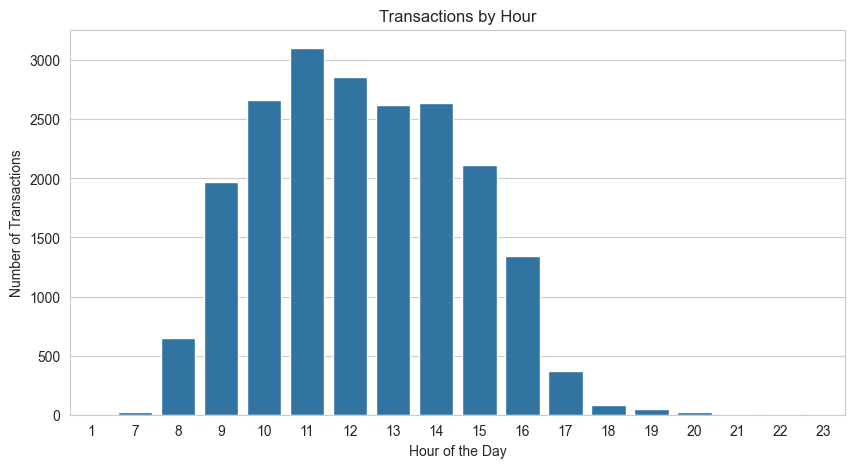

<bound method IndexOpsMixin.tolist of Index(['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend',
       'date', 'time', 'hour', 'day_name', 'month'],
      dtype='object')>


ValueError: Could not interpret value `is_weekend` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [ ]:
## quick visual of the distribution of sales
# Set the plot style
sns.set_style("whitegrid")

#Transactions by Hour
plt.figure(figsize=(10, 5))

sns.countplot(data=df_clean, x="hour")

plt.title("Transactions by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Transactions")

plt.show()

plt.show()

print(df_clean.columns.to_list)

# Weekday vs Weekend
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="weekday_weekend")

plt.title("Weekday vs Weekend Transactions")
plt.xlabel("weekday_weekend")
plt.ylabel("Number of Transactions")

plt.show()

In [46]:
## Save the cleaned data
df_clean.to_csv("../data_set/clean_data/bread_basket_cleaned.csv", index=False)


cleaned data will be saved in the clean_data folder and ready to exploratory data analysis(EDA)

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
